# Import

In [94]:
from parcels import (
        FieldSet,
        JITParticle,
        ScipyParticle,
        ParticleSet,
        AdvectionRK4,
        AdvectionRK4_3D,
        StatusCode,
)
import parcels

import datetime as dt
from datetime import datetime, timedelta

import dask

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import cmocean

import xarray as xr
from xhistogram.xarray import histogram as xhist
from glob import glob
import cartopy
import cartopy.crs as ccrs
from cartopy.crs import Geodetic, PlateCarree
from time import time
import warnings
import shapely
import itertools

warnings.simplefilter("ignore")

# Set Parameters

In [2]:
release_depth = 0
relative_particle_speed = 1

In [3]:
# # zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Fucus_BSH_20210101-20210129_dt60min_N43600_seed123.zarr")
# zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2022/Fucus_BSH_20220101-20220625_dt60min_N453440_seed123.zarr")
# ds_trajectories = xr.open_zarr(zarr_path)#.compute()
# ds_trajectories.nbytes/1e9

In [4]:
output_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories")
zarr_files = sorted(output_path.glob(f"20??/Fucus_BSH_20??????-20??????_dt60min_d{release_depth}_s{relative_particle_speed}_N2*"))
print(np.array(zarr_files))
ds_trajectories = xr.concat([xr.open_zarr(s) for s in zarr_files], dim="trajectory")
ds_trajectories.nbytes/1e9

[PosixPath('/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2019/Fucus_BSH_20190101-20190625_dt60min_d0_s1_N226720_seed123.zarr')
 PosixPath('/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2019/Fucus_BSH_20190701-20191230_dt60min_d0_s1_N235440_seed123.zarr')
 PosixPath('/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2020/Fucus_BSH_20200701-20201230_dt60min_d0_s1_N235440_seed123.zarr')]


160.73264384

In [5]:
ds_trajectories = ds_trajectories.assign(trajectory=np.arange(len(ds_trajectories.trajectory)))

In [6]:
if len(np.unique(ds_trajectories.isel(obs=0).z.compute())) > 1:
        ds_traj = ds_trajectories.isel(obs=0).groupby("z")
        ds_trajectories = ds_trajectories.sel(trajectory=ds_traj[0].trajectory.values)
        # ds_trajectories = ds_trajectories.sel(trajectory=ds_traj[1].trajectory.values)
else:
        ds_trajectories = ds_trajectories.drop("z")
ds_trajectories.nbytes/1e9

128.58723584

In [7]:
try: ds_trajectories = ds_trajectories.rename(dict(CellID="cell_ID"))
except: ""
list_cell_ID = ds_trajectories.cell_ID.isel(obs=0).astype(int)

In [8]:
release_area_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))
gdf_release_area = gdf_release_area.loc[(gdf_release_area.F_vesiculo != 0).values, ["geometry", "CELLCODE",]]

subbasins_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/HELCOM_subbasins_2022_level2")
gdf_subbasins_area = gpd.read_file(Path(subbasins_path, "HELCOM_subbasins_2022_level2.shp"))
gdf_subbasins_area = gdf_subbasins_area.to_crs(crs=ccrs.Geodetic()).rename(dict(level_2="subbasin"), axis=1)

In [9]:
subbasins_simple = gdf_subbasins_area.set_index("subbasin").geometry.buffer(0.2).buffer(-0.2).exterior
release_centroid = gpd.GeoDataFrame(gdf_release_area.CELLCODE, geometry=gdf_release_area.geometry.centroid)
gdf_release_area = gpd.sjoin_nearest(
        left_df=release_centroid, 
        right_df=gdf_subbasins_area, 
        how="left", 
        rsuffix="basin_",
)[["CELLCODE", "subbasin", "geometry"]]

In [10]:
try: ds_trajectories.lat.isel(trajectory=0).compute()
except: ds_trajectories = ds_trajectories.isel(obs=slice(2112))

In [11]:
# def calc_dist(ds):
#         ds = ds[["lon", "lat"]]
#         dist = 111e3 * (
#                 ((ds - ds.isel(obs=0, drop=True)) ** 2).to_array() 
#                 * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
#         ).sum(dim="variable")**0.5
#         return dist.where(ds.lon.notnull()).rename("dist")

In [12]:
earth_radius = 6271.0
degrees_to_radians = np.pi / 180.0
radians_to_degrees = 180.0 / np.pi

def dlat_to_dkm(dlat):
        return dlat * earth_radius * degrees_to_radians
def dlon_to_dkm(latitude, dlon):
        r = earth_radius * np.cos(np.multiply(latitude, degrees_to_radians))
        return dlon / r * degrees_to_radians
def latlon_dist_to_km(ds):
        dlat = ds.lat - ds.lat.isel(obs=0, drop=True)
        return ((dlat_to_dkm(dlat)**2 + dlon_to_dkm(ds.lat + dlat/2, ds.lon - ds.lon.isel(obs=0, drop=True))**2)**.5).rename("dist")

In [13]:
ds_trajectories = ds_trajectories.assign(dict(
        distance=latlon_dist_to_km(ds_trajectories),
        subbasin=("trajectory", gdf_release_area.loc[list_cell_ID].subbasin.values),
        # cell_code=("trajectory", cell_codes),
))

In [14]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int).compute()
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

ds_trajectories = ds_trajectories.where(last_step.distance.drop("obs") > 10, drop=True)

In [15]:
lon_min, lon_max = (5,32)
lat_min, lat_max = (53,66)
central_longitude = np.mean((lon_min, lon_max))
central_latitude = np.mean((lat_min, lat_max))

In [16]:
def calc_hist_0(ds, lon_bins, lat_bins, dims=["trajectory"]):
        return xhist(
                ds.lon, ds.lat,
                bins=[lon_bins, lat_bins],
                dim=dims,
        ).rename(dict(lon_bin="lon",lat_bin="lat"))

In [17]:
def calc_hist_1(ds, lon_bins, lat_bins, dims=["trajectory"], weights=None, ):
        return (
                xhist(
                        ds.lon, ds.lat,
                        bins=[lon_bins, lat_bins],
                        dim=dims,
                        weights=weights,
                ).rename(dict(lon_bin="lon",lat_bin="lat")) 
                / calc_hist_0(ds, lon_bins, lat_bins, dims)
        )

# Schleswig-Holstein
Reduce to SH Coast

In [18]:
administrative_borders = gpd.read_file("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/_ags_Administrative_boundaries/Administrative_boundaries.shp")
administrative_borders = administrative_borders.to_crs(crs=ccrs.Geodetic())
sh_border = administrative_borders.set_index("NAME").loc[["Schleswig-Holstein"]].to_crs(crs=ccrs.Geodetic())

In [19]:
folder_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal")
sh_coast_split = gpd.read_file(Path(folder_path, "output/SamplePoints/sh_baltic_coast_split.geojson")).sort_values("names")

In [20]:
gdf_SH_release = gdf_release_area.cx[:12, :55].clip(sh_coast_split.buffer(.2)).sjoin_nearest(sh_coast_split).rename(columns=dict(names="SH-Coast")).drop(columns="index_right")

In [21]:
gdf_release_area_F = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))

gdf_release_area_F = gdf_release_area_F.loc[(gdf_release_area_F.F_vesiculo != 0).values, ["geometry", "CELLCODE", "F_vesiculo", "CELLID"]]
gdf_SH_release_areas = gdf_SH_release.drop_duplicates(subset="CELLCODE").drop(columns=["geometry", "subbasin"]).join(gdf_release_area_F, rsuffix="_r").drop(columns="CELLCODE_r")

In [22]:
# folder_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal")
# output_path = Path(folder_path, "output/SamplePoints")
# gpd.GeoDataFrame(gdf_SH_release_areas).to_file(Path(output_path, "sh_baltic_coast_release_areas.geojson", driver="GeoJSON"))

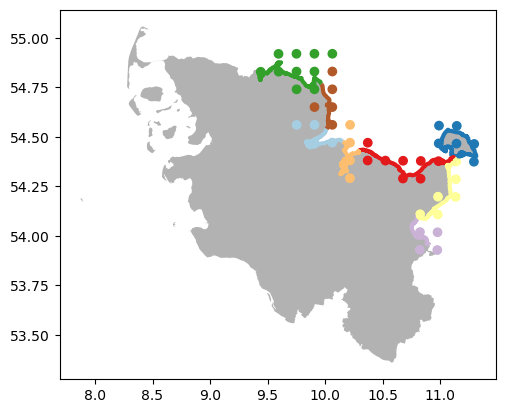

In [23]:
fig, ax = plt.subplots()
sh_border.plot(ax=ax, alpha=.6, color="gray")
sh_coast_split.plot(cmap="Paired", ax=ax, lw=3)
gdf_SH_release.plot(ax=ax, column="SH-Coast", cmap="Paired",)
plt.show()

In [24]:
ds_SH = ds_trajectories.isel(trajectory=ds_trajectories.cell_ID.isin(gdf_SH_release.index).compute().any(dim="obs"))
sh_coast_IDs = gdf_SH_release.loc[ds_SH.cell_ID.isel(obs=0)][["SH-Coast"]].values.T[0]
ds_SH = ds_SH.assign(dict(sh_coast=("trajectory", sh_coast_IDs),)).sortby("sh_coast")

In [25]:
n_bins = 120
ds_plot_count = ds_SH.groupby("subbasin").apply(
        lambda ds:
        calc_hist_0(
                ds.unstack(),
                np.linspace(lon_min, lon_max, n_bins),
                np.linspace(lat_min, lat_max, n_bins),
                dims=["trajectory"],
        )
).compute()

KeyboardInterrupt: 

In [ ]:
ds_plot_age = ds_SH.groupby("subbasin").apply(
        lambda ds: 
        calc_hist_1(
                ds,
                np.linspace(lon_min, lon_max, 120),
                np.linspace(lat_min, lat_max, 120),
                dims=["trajectory", "obs"],
                weights=ds.obs,
        )
).compute()

In [26]:
subbasins_simple = gdf_subbasins_area.set_index("subbasin").geometry.buffer(0.2).buffer(-0.2).exterior

# Maps

## Heatmap

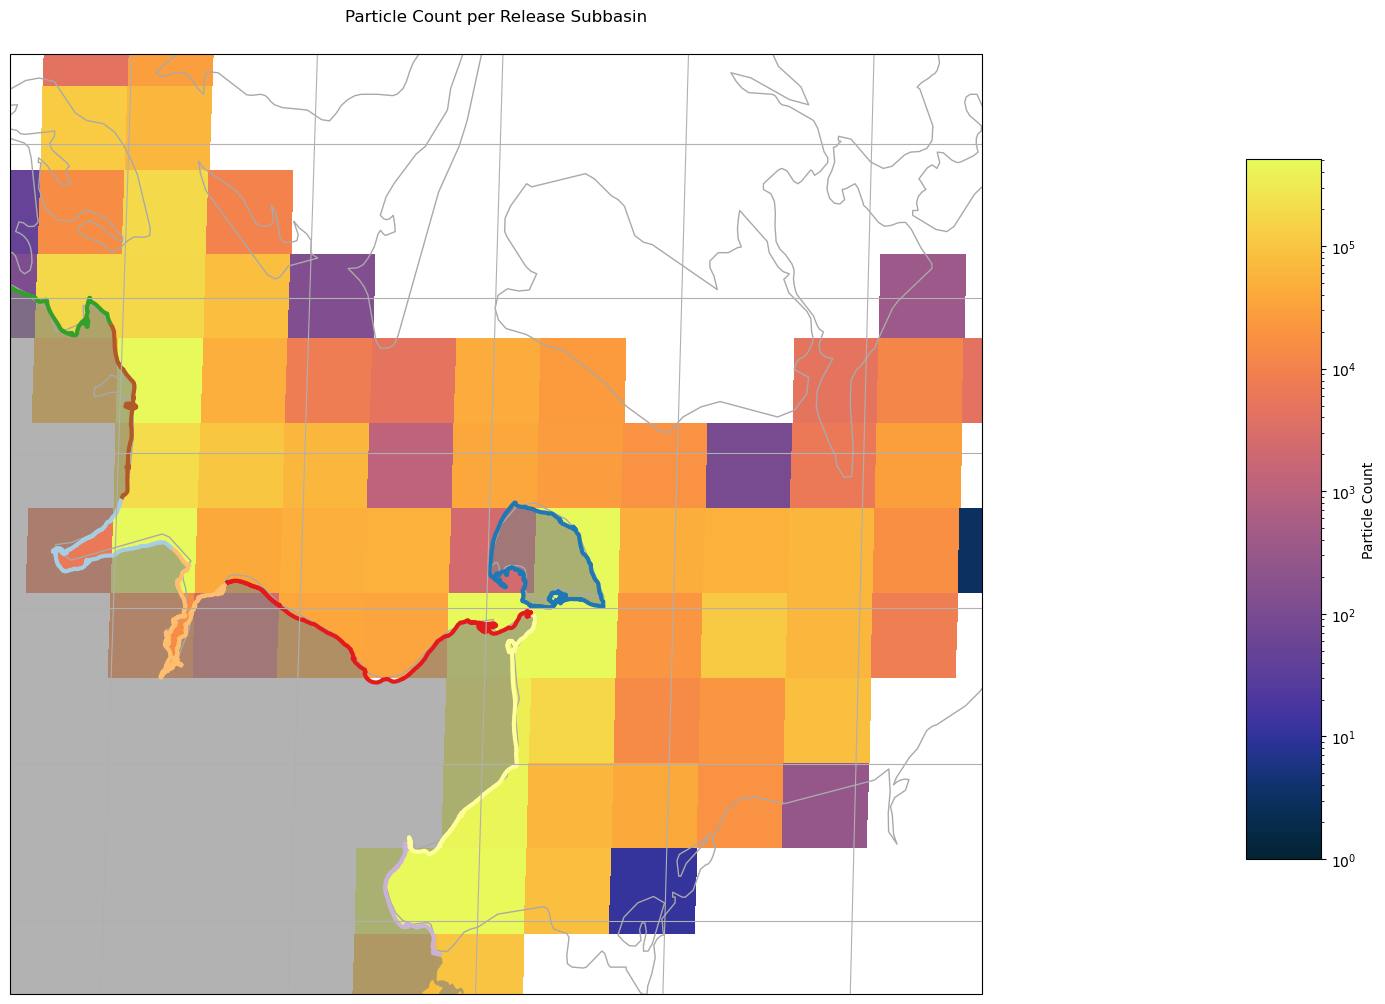

In [26]:
ds_plot_sum = ds_plot_count.sum(dim=("obs", "subbasin"))
vmin, vmax = list(ds_plot_sum.where(ds_plot_sum.notnull() & (ds_plot_sum > 0)).quantile([0.05, 0.95]))
vmin = 1
fig, ax = plt.subplots(
        figsize=(15, 10),
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Particle Count per Release Subbasin", y=1)
im = ds_plot_sum.plot.pcolormesh(
        x="lon", y="lat", ax=ax, 
        norm=LogNorm(vmin=vmin, vmax=vmax), 
        cmap=cmocean.cm.thermal,
        add_colorbar=False, transform=ccrs.PlateCarree(),
)
sh_border.plot(ax=ax, alpha=.6, color="gray", transform=ccrs.Geodetic())
sh_coast_split.plot(cmap="Paired", ax=ax, lw=3, transform=ccrs.Geodetic())
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=False)
ax.set_extent((ds_SH.lon.min(), ds_SH.lon.max(), ds_SH.lat.min(), ds_SH.lat.max()))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Particle Count")
fig.tight_layout()
plt.show()

## Agemap

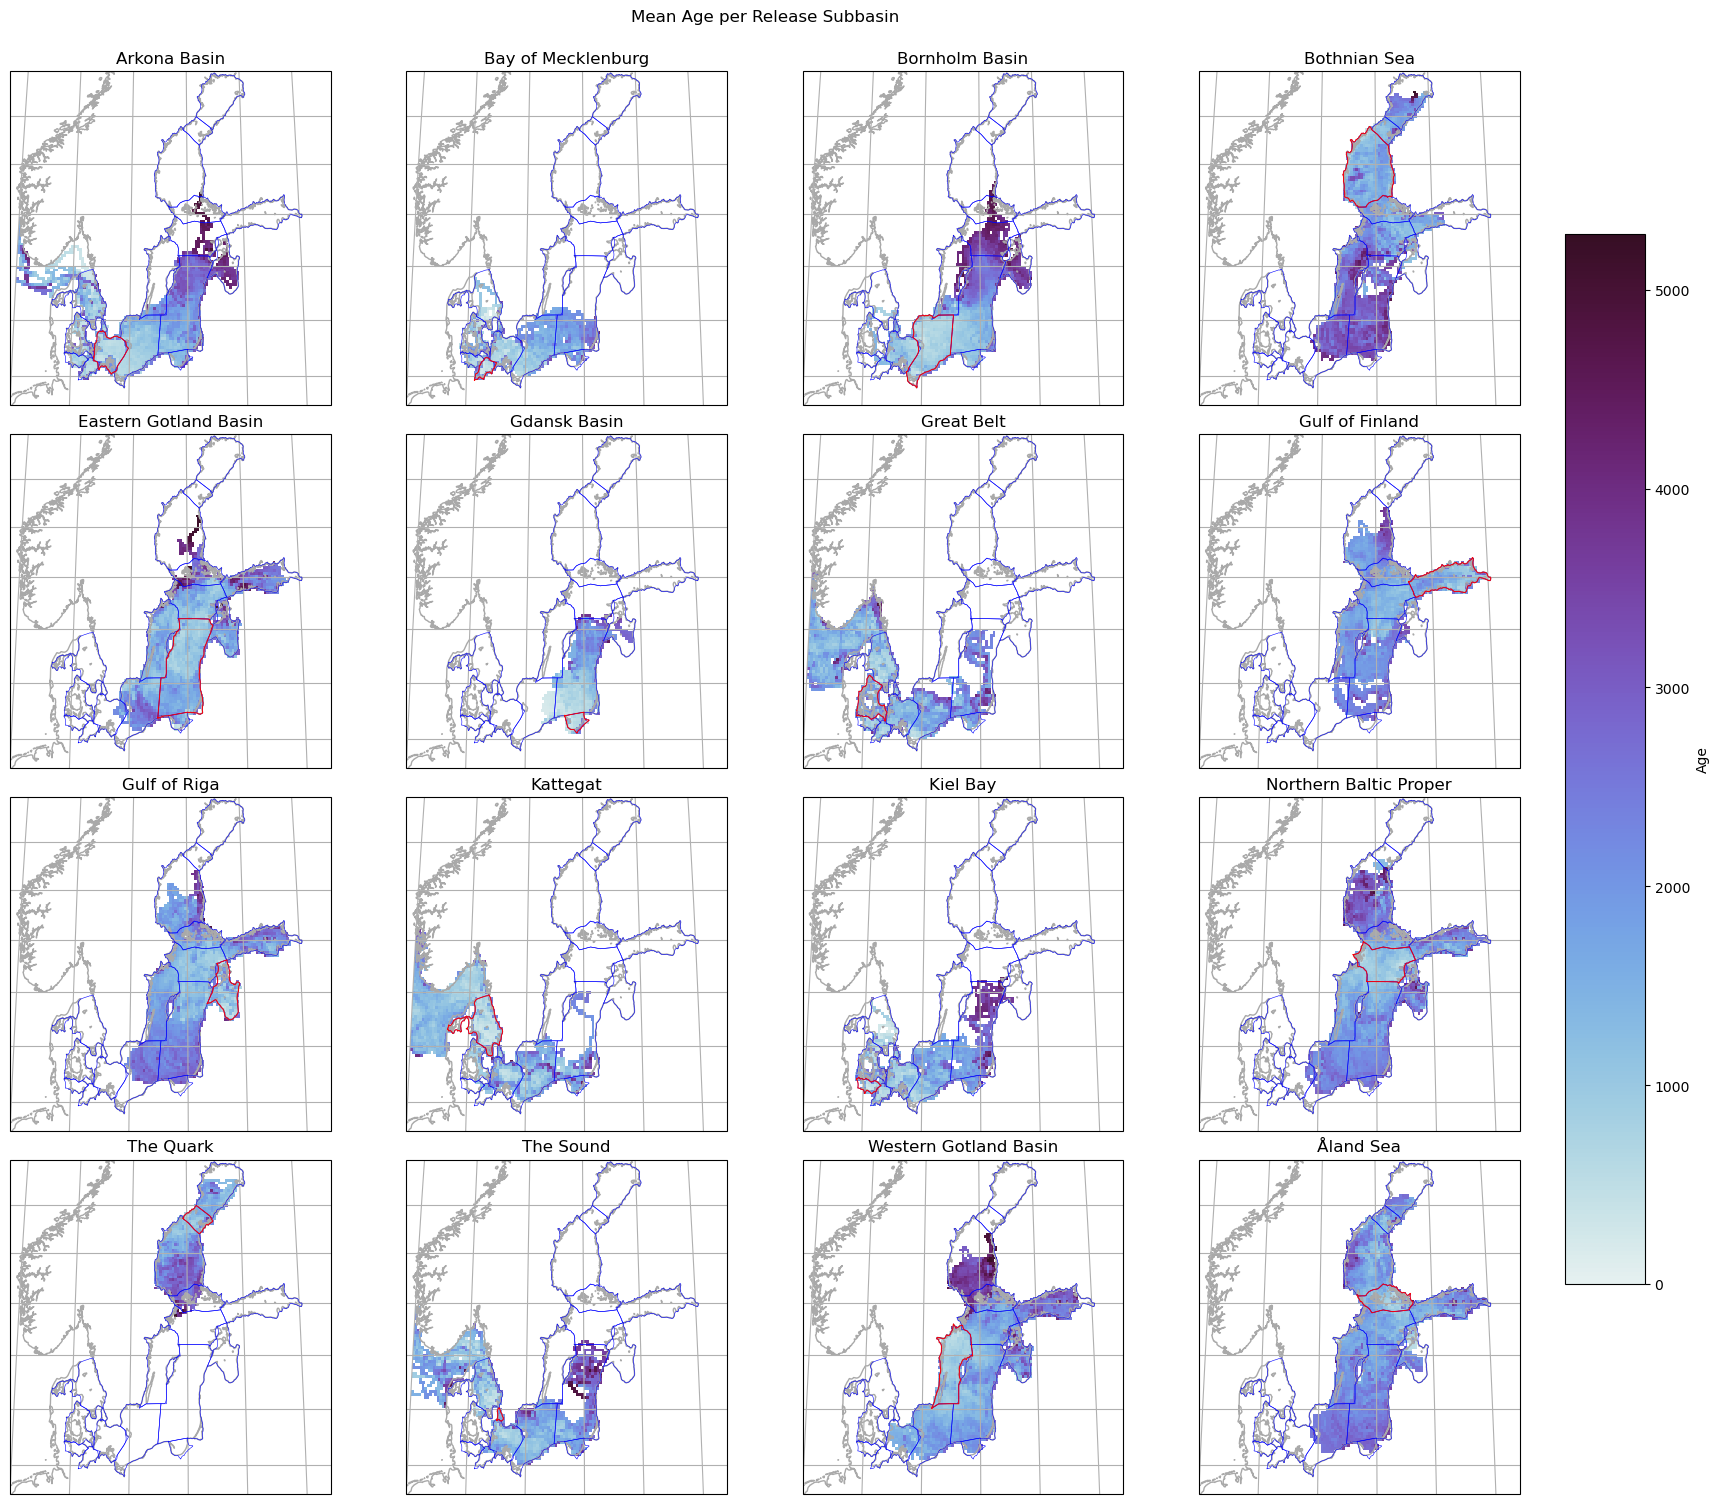

In [130]:
vmin = 0
vmax = 220*24
fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Mean Age per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot_1.subbasin.values):
        subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        ax.plot(*subbasins_simple.loc[basin].xy, transform=ccrs.PlateCarree(), color="r", lw=.7, zorder=30,)
        im = ds_plot_1.sel(subbasin=basin).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                cmap=cmocean.cm.dense,
                vmin=vmin, vmax=vmax, 
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

# Regional SH Plots

## Animations

In [87]:
# ds_trajectories["age"] = ds_SH.age_sec.isel(trajectory=0).compute().astype('timedelta64[s]')

<xarray.DataArray 'age_sec' (obs: 5760)> Size: 46kB
array([ 900000000000, 4500000000000, 8100000000000, ...,         'NaT',
               'NaT',         'NaT'], dtype='timedelta64[ns]')
Coordinates:
  * obs         (obs) int32 23kB 0 1 2 3 4 5 6 ... 5754 5755 5756 5757 5758 5759
    trajectory  int64 8B 2
Attributes:
    long_name:      
    standard_name:  age_sec
    units:          unknown

In [29]:
# ds_scatter_ani = xr.merge((ds_SH, ds_trajectories.time.isel(obs=0).compute()), join="left")
# ds_scatter_ani = ds_scatter_ani.where(ds_scatter_ani.trajectory==ds_trajectories.trajectory).sortby("sh_coast")

In [25]:
sh_lon_min=np.floor(ds_SH.lon.min()).compute()
sh_lon_max=np.ceil(ds_SH.lon.max()).compute()
sh_lat_min=np.floor(ds_SH.lat.min()).compute()
sh_lat_max=np.ceil(ds_SH.lat.max()).compute()
sh_lon_range = sh_lon_max - sh_lon_max
sh_lat_range = sh_lat_max - sh_lat_min

In [55]:
lon_min = sh_lon_min - sh_lon_range/10
lon_max = sh_lon_max + sh_lon_range/10
lat_min = sh_lat_min - sh_lat_range/10
lat_max = sh_lat_max + sh_lat_range/10
extent = (lon_min, lon_max, lat_min, lat_max)

In [27]:
age = ds_SH.isel(trajectory=0).age_sec.compute()/60/60/24

In [28]:
# ds_scatter_ani = ds_SH.groupby_bins(group="obs", bins=220).mean(dim="obs", skipna=True).rename(dict(obs_bins="obs")).compute()

In [258]:
end_point=24*20
bins=np.arange(0, ds_SH.obs.max() , 8)
# bins=np.arange(0, end_point, 1)
ds_scatter_ani = ds_SH.groupby_bins(group="obs", bins=bins).mean(dim="obs", skipna=True).rename(dict(obs_bins="obs")).compute()

In [ ]:
da_time_b = ds_trajectories.time.isel(obs=bins.astype(int)).sel(trajectory=ds_scatter_ani.trajectory).compute()

<xarray.DataArray 'time' (obs: 720)> Size: 6kB
array(['2019-01-01T06:00:00.000000000', '2019-01-01T14:00:00.000000000',
       '2019-01-01T22:00:00.000000000', '2019-01-02T06:00:00.000000000',
       '2019-01-02T14:00:00.000000000', '2019-01-02T22:00:00.000000000',
       '2019-01-03T06:00:00.000000000', '2019-01-03T14:00:00.000000000',
       '2019-01-03T22:00:00.000000000', '2019-01-04T06:00:00.000000000',
       '2019-01-04T14:00:00.000000000', '2019-01-04T22:00:00.000000000',
       '2019-01-05T06:00:00.000000000', '2019-01-05T14:00:00.000000000',
       '2019-01-05T22:00:00.000000000', '2019-01-06T06:00:00.000000000',
       '2019-01-06T14:00:00.000000000', '2019-01-06T22:00:00.000000000',
       '2019-01-07T06:00:00.000000000', '2019-01-07T14:00:00.000000000',
       '2019-01-07T22:00:00.000000000', '2019-01-08T06:00:00.000000000',
       '2019-01-08T14:00:00.000000000', '2019-01-08T22:00:00.000000000',
       '2019-01-09T06:00:00.000000000', '2019-01-09T14:00:00.000000000',
       '2019-01-09T22:00:00.000000000', '2019-01-10T06:00:00.000000000',
       '2019-01-10T14:00:00.000000000', '2019-01-10T22:00:00.000000000',
       '2019-01-11T06:00:00.000000000', '2019-01-11T14:00:00.000000000',
       '2019-01-11T22:00:00.000000000', '2019-01-12T06:00:00.000000000',
       '2019-01-12T14:00:00.000000000', '2019-01-12T22:00:00.000000000',
       '2019-01-13T06:00:00.000000000', '2019-01-13T14:00:00.000000000',
       '2019-01-13T22:00:00.000000000', '2019-01-14T06:00:00.000000000',
...
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT'],
      dtype='datetime64[ns]')
Coordinates:
  * obs         (obs) int32 3kB 0 8 16 24 32 40 ... 5720 5728 5736 5744 5752
    trajectory  int64 8B 1
Attributes:
    axis:           T
    long_name:      
    standard_name:  time

In [257]:
# da_time_b = ds_trajectories.time.isel(obs=bins.astype(int)).sel(trajectory=ds_scatter_ani.trajectory).compute()
da_releasetime = ds_trajectories.time.isel(obs=0).sel(trajectory=ds_scatter_ani.trajectory).compute()
da_time = ds_trajectories.time.isel(obs=bins.astype(int), trajectory=0).compute()

In [260]:
# da_time = ds_trajectories.time.compute()
ds_scatter_ani = ds_scatter_ani.assign(
        dict(
                age=("obs",(da_time - da_releasetime.isel(trajectory=0)).values[:-1]),
                release_time=("trajectory", da_releasetime.values)
        )
)

In [ ]:
# # da_time = ds_trajectories.time.compute()
# ds_scatter_ani = ds_scatter_ani.assign(
#         dict(
#                 age=("obs",(da_time_b.isel(trajectory=0) - da_time_b.isel(trajectory=0, obs=0)).values[:-1]),
#                 release_time=("trajectory",(da_time_b.isel(obs=0)).values)
#         )
# )

In [ ]:
# da_time = ds_trajectories.time.isel(trajectory=0).compute()
# ds_scatter_ani = ds_scatter_ani.assign(dict(age=("obs",(da_time.isel(obs=bins.astype(int)) - da_time.isel(obs=0)).values[:-1])))

In [261]:
ds_scatter_ani = ds_scatter_ani.where(ds_scatter_ani.age.notnull(), drop=True)

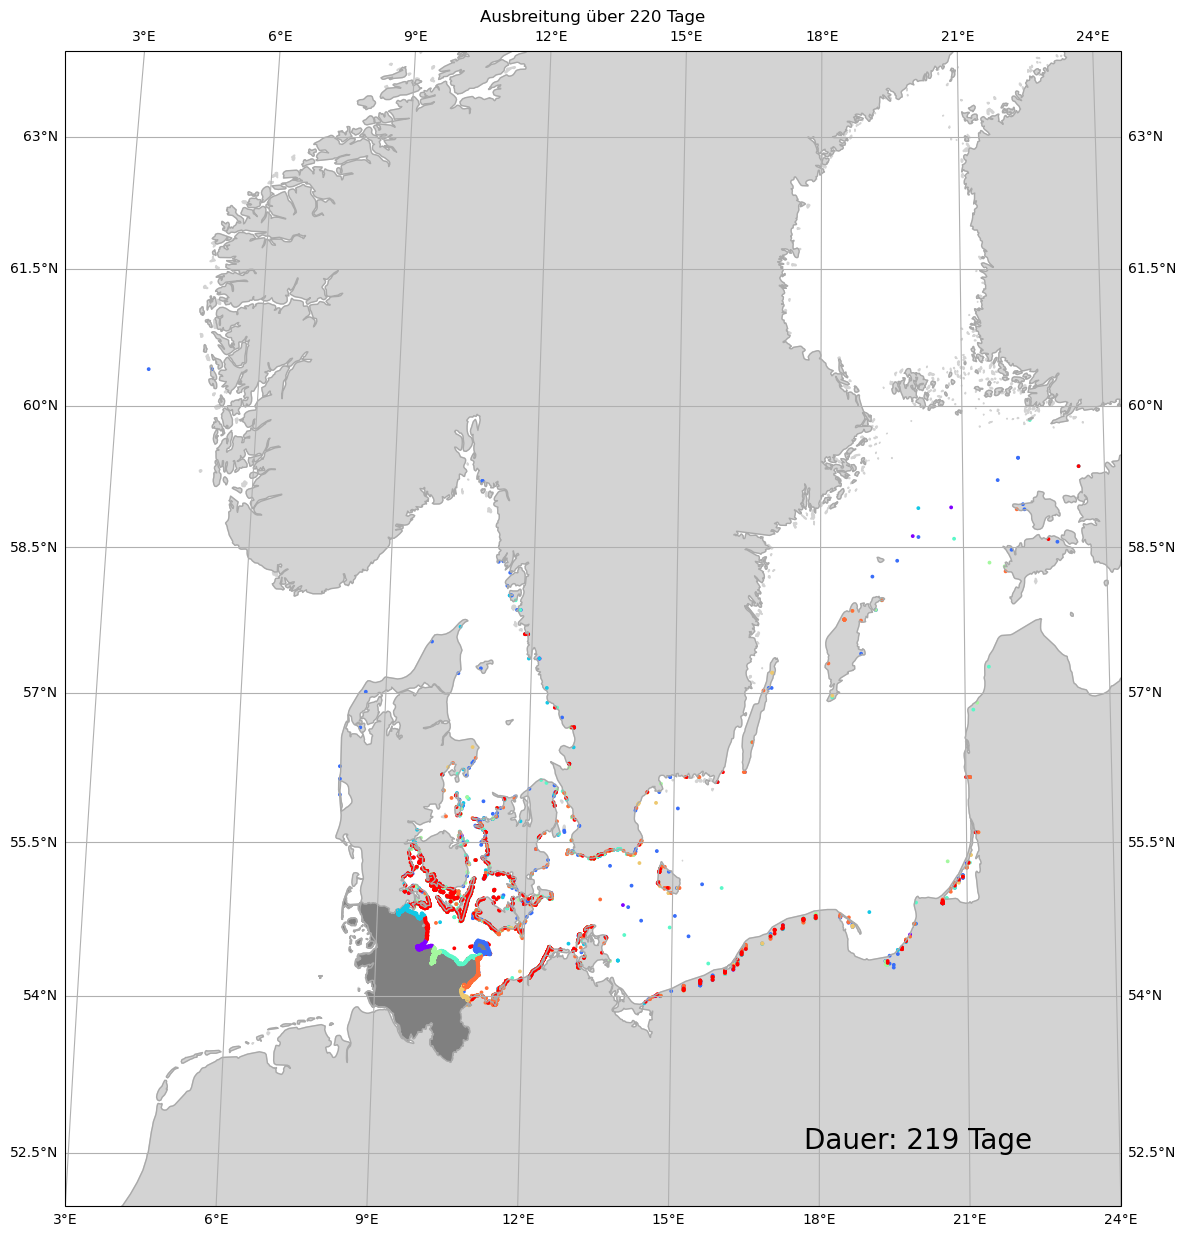

In [108]:
colors = pd.factorize(ds_scatter_ani.isel(obs=0).sh_coast)
cmap = "rainbow"
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)
ax.set_title("Ausbreitung über 220 Tage")
scat = ax.scatter(
        ds_scatter_ani.isel(obs=0).lon,
        ds_scatter_ani.isel(obs=0).lat,
        c=colors[0], label=colors[1],
        cmap=cmap, s=3,
        transform=Geodetic(),
)
ax.add_feature(cartopy.feature.LAND, color="lightgrey")
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent(extent)

sh_border.plot(ax=ax, color="gray", edgecolor="darkgray", transform=Geodetic())
sh_coast_split.plot(ax=ax, cmap=cmap, lw=3, transform=Geodetic())

time_text = ax.text(0.7, 0.05, "Dauer: 0 Tage", transform=ax.transAxes, size=20)

def animate(frame):
        time_text.set_text("Dauer: "+str(ds_scatter_ani.age[frame].dt.days.values)+" Tage")
        ds = ds_scatter_ani.isel(obs=frame)
        scat.set_offsets(np.stack([ds.lon.values, ds.lat.values], axis=1))

ani = animation.FuncAnimation(fig, func=animate, interval=100, frames=len(ds_scatter_ani.obs)-1,)
# ani.save(filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_scatter_surface_100.gif", writer="pillow")
ani.save(filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_scatter_surface_100_d0-220.mp4", writer="ffmpeg")
plt.show()

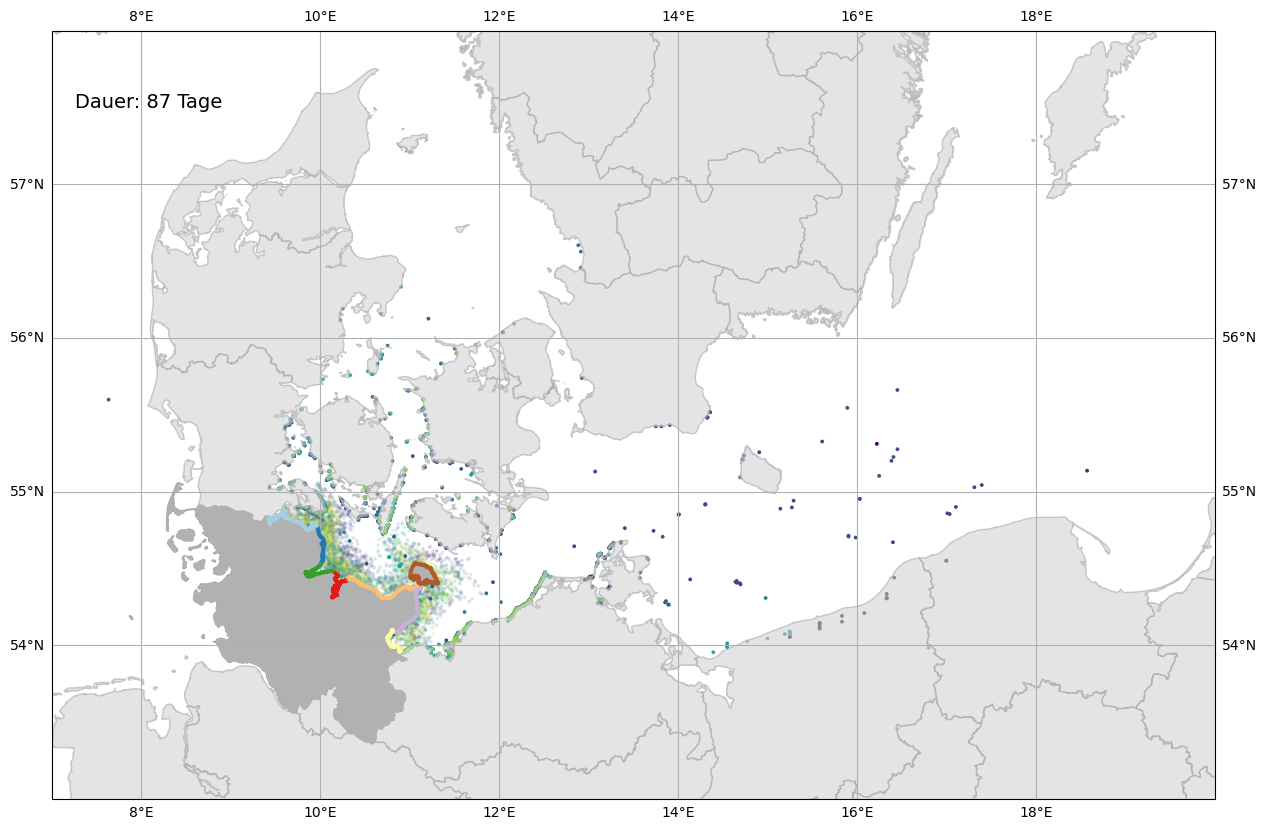

In [ ]:
# lon_min=7
# lon_max=np.ceil(ds_scatter_ani.lon.max())
# lat_min=53
# lat_max=58
# fig, ax = plt.subplots(
#         figsize=(15,15),
#         subplot_kw=dict(projection=ccrs.PlateCarree()), 
# )

# x_initial = ds_scatter_ani.lon.T
# y_initial = ds_scatter_ani.lat.T
# ax.scatter(
#         ds_scatter_ani.isel(obs=0).lon.T,
#         ds_scatter_ani.isel(obs=0).lat.T,
#         alpha=.1,
#         c=pd.factorize(ds_scatter_ani.time.to_numpy())[0],
#         s=3, transform=ccrs.PlateCarree(),
# )
# scat = ax.scatter(
#         ds_scatter_ani.isel(obs=0).lon.T,
#         ds_scatter_ani.isel(obs=0).lat.T,
#         c=pd.factorize(ds_scatter_ani.time.to_numpy())[0],
#         s=3, transform=ccrs.PlateCarree(),
# )
# ax.gridlines(draw_labels=True)
# ax.set_extent((lon_min, lon_max, lat_min, lat_max))
# time_text = ax.text(
#         0.02, 0.9,
#         "Dauer: "+str(timedelta(seconds=int(ds_scatter_ani.age_sec.isel(trajectory=0, obs=0).values)).days)+" Tage",
#          transform=ax.transAxes, size=14,)

# sh_border.plot(ax=ax, color="gray", transform=ccrs.Geodetic(), edgecolor="darkgray")
# administrative_borders.cx[lon_min:lon_max, lat_min:lat_max].plot(ax=ax, alpha=.6, color="lightgray", transform=ccrs.Geodetic(), edgecolor="darkgray")
# sh_coast_split.plot(cmap="Paired", ax=ax, lw=3, transform=ccrs.Geodetic())
# def animate(frame):
#         time_text.set_text("Dauer: "+str(timedelta(seconds=int(ds_scatter_ani.age_sec.isel(trajectory=0, obs=frame).values)).days)+" Tage")
#         x = ds_scatter_ani.isel(obs=frame).lon.values
#         y = ds_scatter_ani.isel(obs=frame).lat.values
#         data = np.stack([x,y]).T
#         scat.set_offsets(data)

# ani = animation.FuncAnimation(fig, func=animate, interval=100, 
#         frames=len(ds_scatter_ani.obs),
#         repeat_delay=5000,
# )
# ani.save(
#         filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_scatter.gif", 
#         writer="pillow")
# plt.show()

In [119]:
np.arange(lon_min, lon_max, .125).shape

(168,)

In [125]:
n_bins = 120
ds_sh_coast_count = ds_scatter_ani.groupby("sh_coast").apply(
        lambda ds:
        calc_hist_0(
                ds.unstack(),
                np.arange(lon_min, lon_max, .125),
                np.arange(lat_min, lat_max, .125),
                dims=["trajectory", "obs"],
        )
).compute()

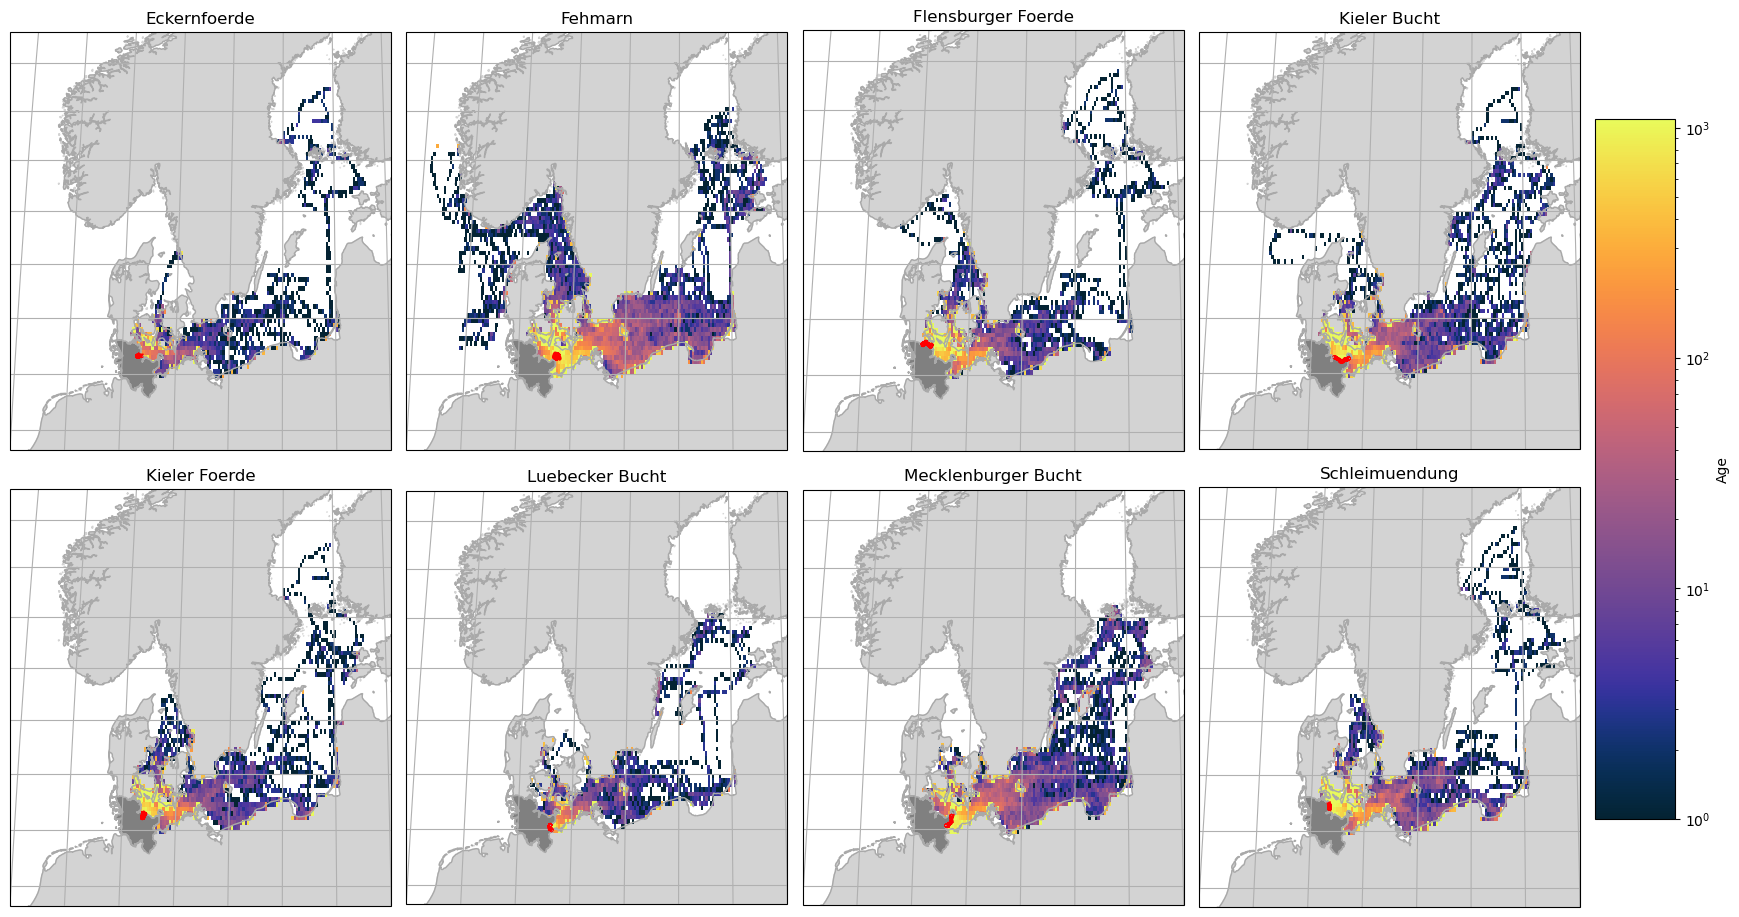

In [248]:
vmax=ds_plot_count.where(ds_plot_count.notnull() & ds_plot_count>0).quantile(0.95)
vmin=1
fig, axes = plt.subplots(
        figsize=(16, 10),
        nrows=2, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)
for ax, coast_part in zip(axes.flatten(), ds_plot_count.sh_coast.values):
        # subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        im = ds_plot_count.sel(sh_coast=coast_part).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                cmap=cmocean.cm.thermal,
                norm=LogNorm(vmin=vmin, vmax=vmax), 
                add_colorbar=False, transform=PlateCarree(),
        )
        ax.set_title(coast_part)
        ax.add_feature(cartopy.feature.LAND, color="lightgrey")
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent(extent)
        sh_border.plot(ax=ax, color="gray", edgecolor="darkgray", transform=Geodetic())
        sh_coast_split.where(sh_coast_split.names==coast_part).dropna().plot(ax=ax, cmap=cmap, lw=3, transform=Geodetic(), color="r")

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

In [ ]:
# n_bins = 120
ds_month_count = ds_scatter_ani.groupby("release_time.month").apply(
        lambda ds:
        calc_hist_0(
                ds.unstack(),
                np.arange(lon_min, lon_max, .125),
                np.arange(lat_min, lat_max, .125),
                dims=["trajectory", "obs"],
        )
).compute()

AttributeError: 'DatetimeAccessor' object has no attribute 'month.strftime('

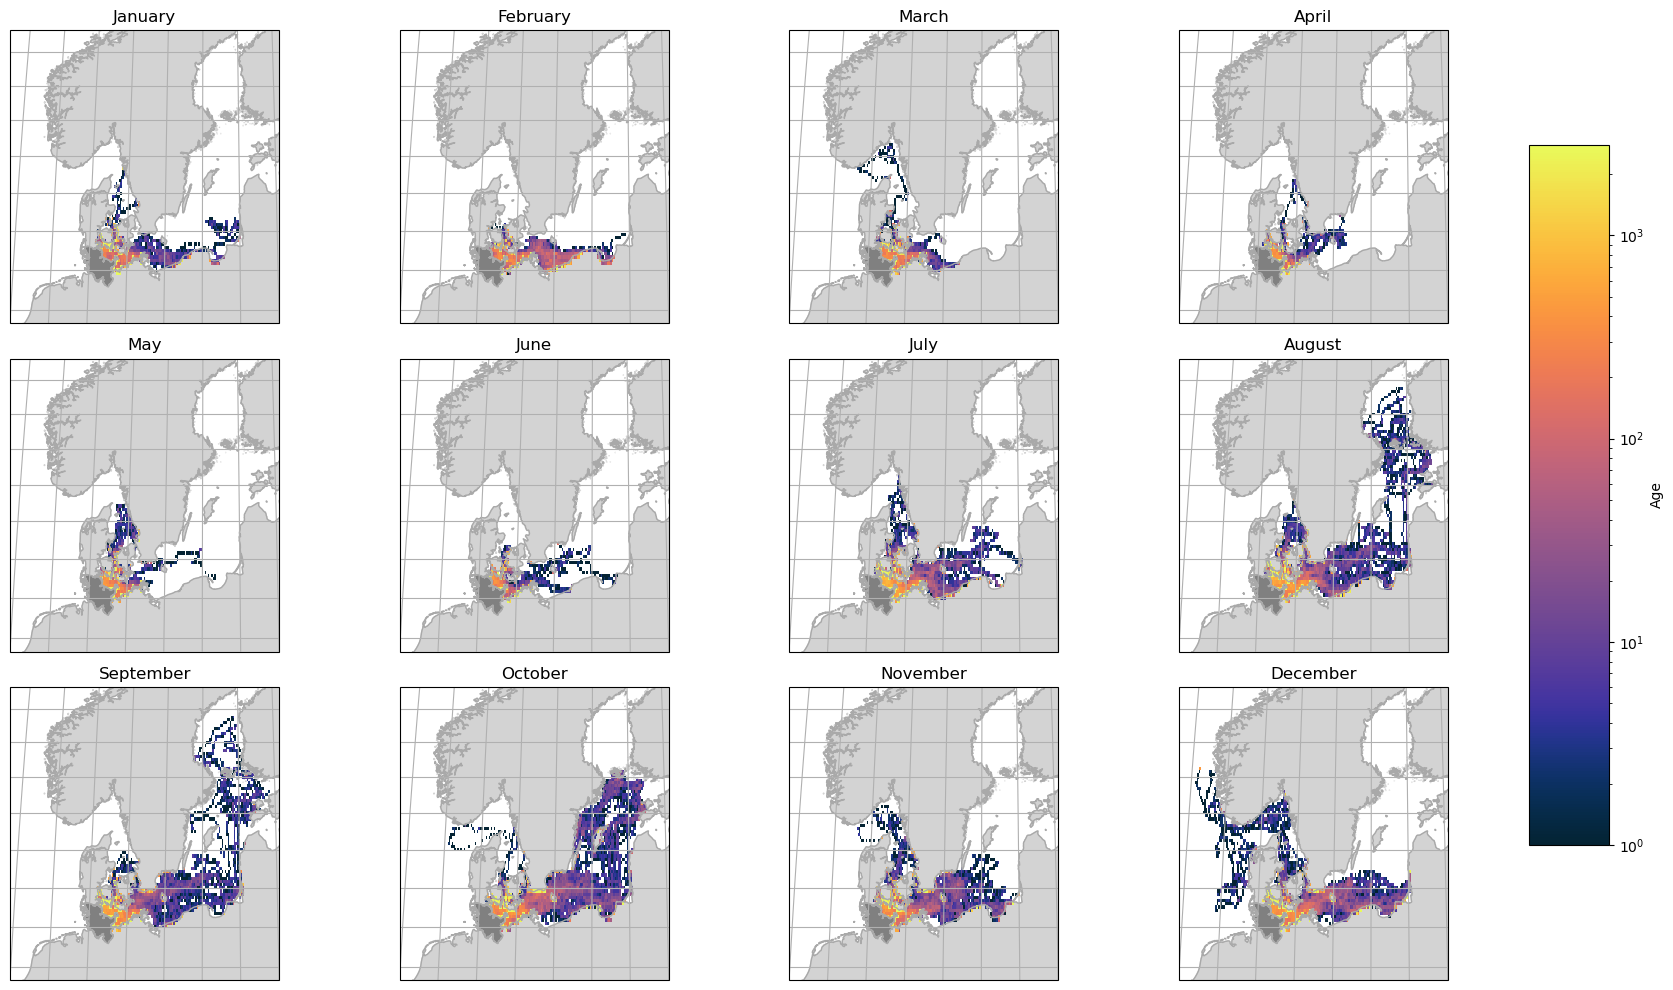

In [249]:
vmax=ds_month_count.where(ds_month_count.notnull() & ds_month_count>0).quantile(0.95)
vmin=1
# lon_min, lon_max, lat_min, lat_max = ds_plot_count.lon.min(), ds_plot_count.lon.max(), ds_plot_count.lat.min(), ds_plot_count.lat.max()
fig, axes = plt.subplots(
        figsize=(16, 10),
        nrows=3, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)
for ax, month in zip(axes.flatten(), ds_month_count):
        # subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        im = month.plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                cmap=cmocean.cm.thermal,
                norm=LogNorm(vmin=vmin, vmax=vmax), 
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(datetime(year=2019, month=month.month.values, day=1).strftime("%B"))
        ax.add_feature(cartopy.feature.LAND, color="lightgrey")
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent(extent)
        sh_border.plot(ax=ax, color="gray", edgecolor="darkgray", transform=Geodetic())
        # sh_coast_split.plot(ax=ax, cmap=cmap, lw=3, transform=Geodetic())

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

In [124]:
ds_plot_count.sum(dim="sh_coast")

<xarray.DataArray 'histogram_lon_lat' (lon: 167, lat: 95)> Size: 127kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
  * lon      (lon) float64 1kB 3.062 3.188 3.312 3.438 ... 23.56 23.69 23.81
  * lat      (lat) float64 760B 52.06 52.19 52.31 52.44 ... 63.56 63.69 63.81

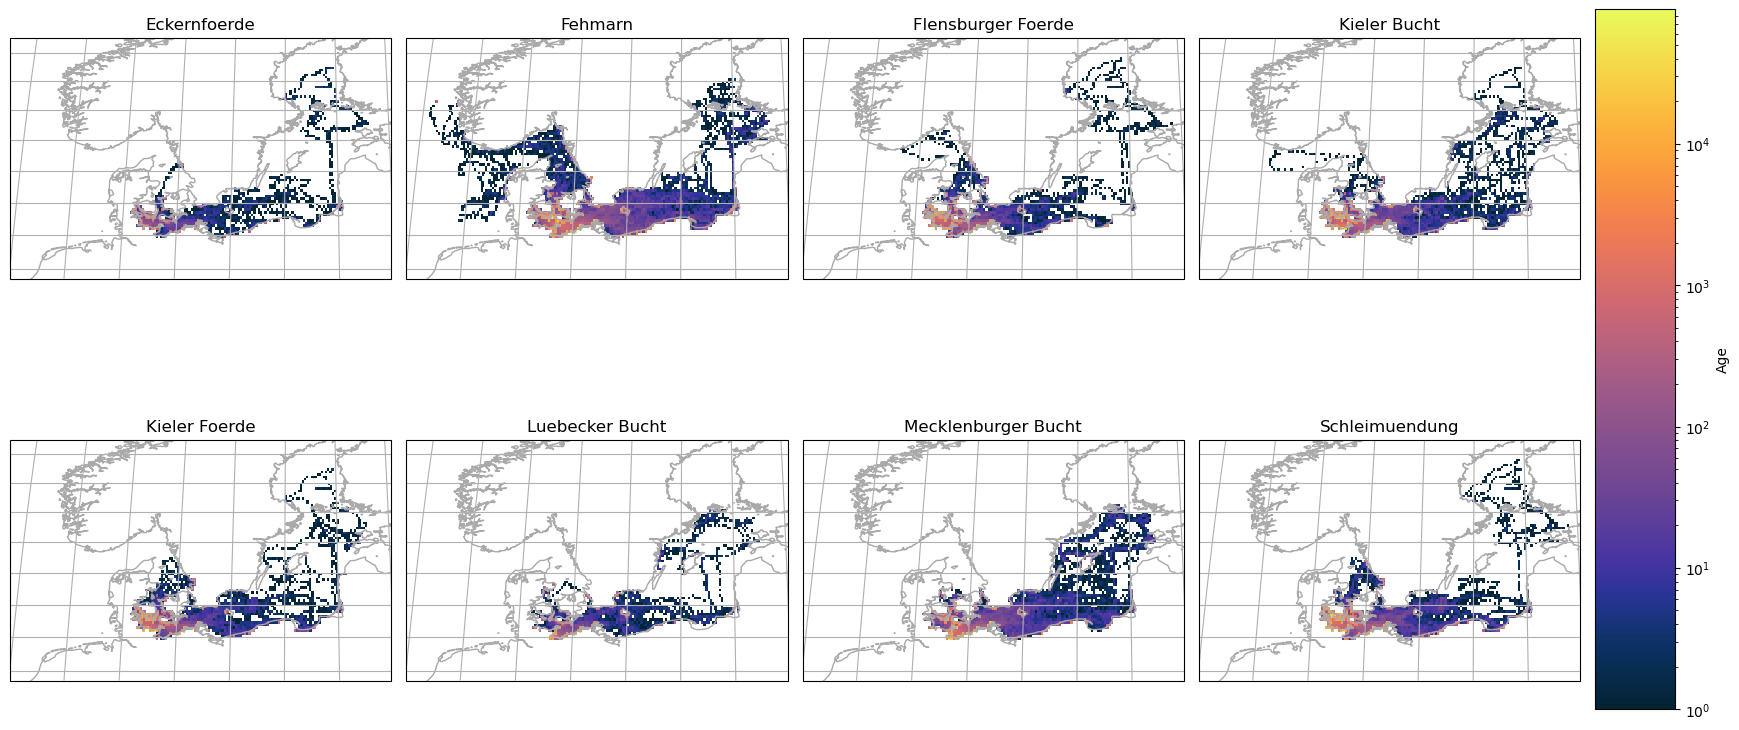

In [ ]:
vmax=ds_plot_count.max()
vmin=1
# lon_min, lon_max, lat_min, lat_max = ds_plot_count.lon.min(), ds_plot_count.lon.max(), ds_plot_count.lat.min(), ds_plot_count.lat.max()
fig, axes = plt.subplots(
        figsize=(16, 10),
        nrows=2, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)
for ax, coast_part in zip(axes.flatten(), ds_plot_count.sh_coast.values):
        # subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        im = ds_plot_count.sel(sh_coast=coast_part).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                cmap=cmocean.cm.thermal,
                norm=LogNorm(vmin=vmin, vmax=vmax), 
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(coast_part)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(projection=ccrs.PlateCarree()), 
)

x_initial = ds_scatter_ani.lon.T
y_initial = ds_scatter_ani.lat.T

lines = [ax.plot(x, y, color="lightgrey", linewidth=.4)[0] for x, y in zip(x_initial, y_initial)]

scat = ax.scatter(
        ds_scatter_ani.isel(obs=0).lon.T,
        ds_scatter_ani.isel(obs=0).lat.T,
        s=3, transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_ani.lon.min(), ds_ani.lon.max(), ds_ani.lat.min(), ds_ani.lat.max()))
time_text = ax.text(0.02,0.9,"day=1", transform=ax.transAxes, size=14,)

def animate(frame):
        time_text.set_text(f"day={(int(frame+1))}")
        x = ds_scatter_ani.isel(obs=frame).lon.values
        y = ds_scatter_ani.isel(obs=frame).lat.values
        data = np.stack([x,y]).T
        scat.set_offsets(data)
        for i, line in enumerate(lines):
                x_update = x_initial[i][:frame+1]
                y_update = y_initial[i][:frame+1]
                line.set_xdata(x_update)
                line.set_ydata(y_update)
        return lines

ani = animation.FuncAnimation(fig, func=animate, interval=100, frames=len(ds_scatter_ani.obs))
ani.save(
        filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_scatter_lines.gif", 
        writer="pillow")
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x1465e7635b20> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [225]:
ds_scatter_SH_ani = ds_SH.groupby_bins(group="obs", bins=220).mean(dim="obs").isel(trajectory=slice(50))
ds_scatter_SH_ani

<xarray.Dataset> Size: 1MB
Dimensions:              (obs_bins: 220, trajectory: 50)
Coordinates:
  * trajectory           (trajectory) int64 400B 1 38 58 89 ... 1887 1915 1916
  * obs_bins             (obs_bins) object 2kB (-5.303, 24.105] ... (5278.895...
Data variables: (12/14)
    age_sec              (obs_bins, trajectory) float32 44kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    cell_ID              (obs_bins, trajectory) float64 88kB 5.103e+04 ... 5....
    lat                  (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    lon                  (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    z                    (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    distance             (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    ...                   ...
    valid_obs_count      (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    lat_diff             (obs_bins, trajectory) float64 88kB 0.07922 ... 0.9842
    lon_diff             (obs_bins, trajectory) float64 88kB 0.07524 ... 2.592
    cell_code            (obs_bins, trajectory) object 88kB '10kmE438N347' .....
    age_sec_obs          (obs_bins, trajectory) float32 44kB 4.41e+04 ... 1.9...
    subbasin             (obs_bins, trajectory) object 88kB 'Kiel Bay' ... 'K...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHaging_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [ ]:
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(
                projection=ccrs.PlateCarree()
                ), 
)

x_initial = ds_scatter_SH_ani.lon.T
y_initial = ds_scatter_SH_ani.lat.T

# lines = [ax.plot(x, y, color="lightgrey", linewidth=.4)[0] for x, y in zip(x_initial, y_initial)]

scat = ax.scatter(
        ds_scatter_SH_ani.isel(obs_bins=0).lon.T,
        ds_scatter_SH_ani.isel(obs_bins=0).lat.T,
        s=3, transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_scatter_SH_ani.lon.min(), ds_scatter_SH_ani.lon.max(), ds_scatter_SH_ani.lat.min(), ds_scatter_SH_ani.lat.max()))
time_text = ax.text(0.02,0.9,"day=1", transform=ax.transAxes, size=14,)

def animate(frame):
        time_text.set_text(f"day={(int(frame+1))}")
        x = ds_scatter_SH_ani.isel(obs_bins=frame).lon.values
        y = ds_scatter_SH_ani.isel(obs_bins=frame).lat.values
        data = np.stack([x,y]).T
        scat.set_offsets(data)
        # for i, line in enumerate(lines):
        #         x_update = x_initial[i][:frame+1]
        #         y_update = y_initial[i][:frame+1]
        #         line.set_xdata(x_update)
        #         line.set_ydata(y_update)
        # return lines

ani = animation.FuncAnimation(fig, func=animate, interval=100, frames=len(ds_scatter_SH_ani.obs_bins))
ani.save(
        filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_scatter.gif", 
        writer="pillow")
plt.show()

In [80]:
gdf_baltic_buffed.difference(gdf_baltic).buffer(.2).plot()

KeyboardInterrupt: 

statistics of in which month and from which starting position do the particles travel how far, and the area

In [45]:
def calc_dist_quantiles(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).quantile(np.linspace(0,1,5), dim="trajectory").rename("dist")

In [47]:
df_distance_q = ds_trajectories.groupby("subbasin").apply(calc_dist_quantiles).compute().to_dataframe()

In [ ]:
# df_distance_q.unstack(0).loc[0.5].assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").max()["dist"].plot()


In [46]:
df_distance_m = ds_SH.groupby("sh_coast").mean(dim="obs").distance.to_dataframe()
# df_distance_m = df_distance_m.unstack(0).assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").mean()["dist"]

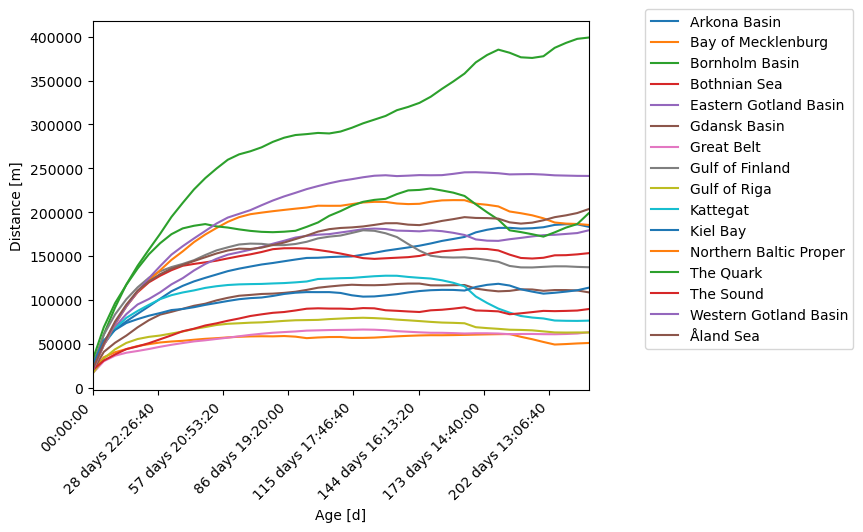

In [ ]:
# fig, ax = plt.subplots(111, figsize=(15,10))
p = df_distance_m.plot()
p.legend(loc="best", bbox_to_anchor=(1.1, 1.05))
# p.tick_params("x", rotation=45,)
plt.xticks(rotation=45, ha="right")
# a =print(p.xaxis.get_ticklabels())
# print(p.xaxis.get_majorticklocs())
# p.xaxis.set_major_formatter()
# p.set_xticklabels(labels=np.timedelta64(1, "D")*np.arange(0, 220, 7))
p.set_xlabel("Age [d]")
p.set_ylabel("Distance [m]")
plt.show()

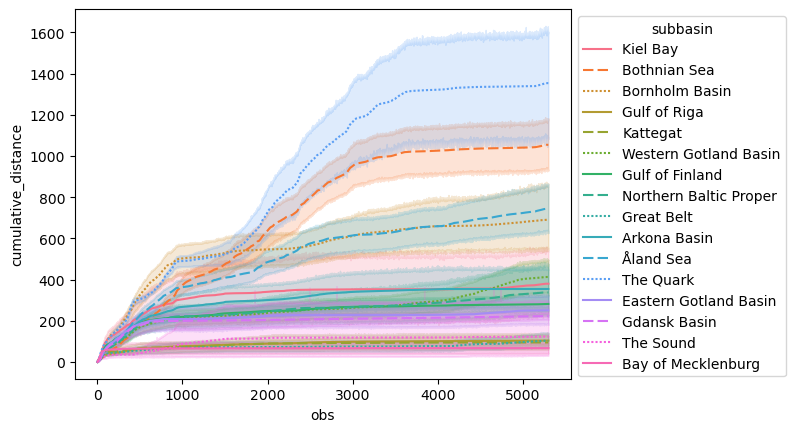

In [ ]:
fig = plt.Figure((15,15))
ax = sns.lineplot(
        data=df, 
        x="obs", y="cumulative_distance",
        hue="subbasin",
        style="subbasin",
        dashes=['', (5, 2), (1, 1)],
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

<Axes: xlabel='total_distance', ylabel='subbasin'>

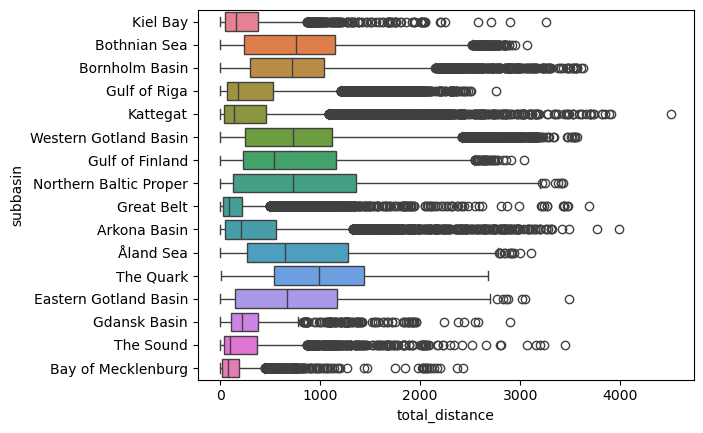

In [103]:
sns.boxplot(df_total, x="total_distance", y="subbasin", hue="subbasin")

In [59]:
basin_names = pd.Index(data=list(subbasin_grouped.groups.keys()), name="subbasins")
basin_idx = pd.Index(data=["trajs", "cells"], name="index")

In [60]:
basins = pd.DataFrame(
        index=basin_names,
        columns=basin_idx,
        data=basin_counts,
)

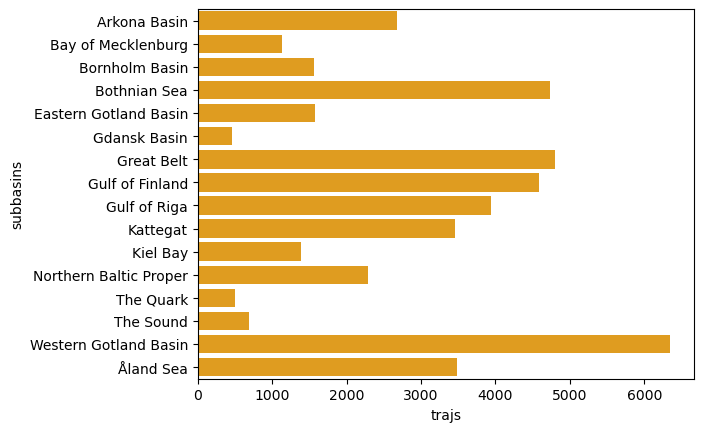

<Axes: xlabel='cells', ylabel='subbasins'>

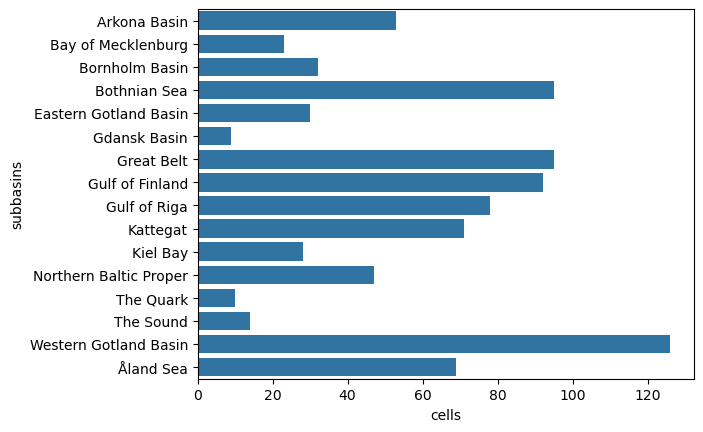

In [61]:
sns.barplot(basins, x="trajs", y="subbasins", color="orange")
plt.show()
sns.barplot(basins, x="cells", y="subbasins")

In [ ]:
mean_total_distance_per_cell = ds_trajectories.total_distance.groupby("cell_code").mean()
mean_total_distance_per_cell

In [ ]:
# open depth files and define depth cmap
path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
path_static_fine = path_static_files / "static_file_fine"
path_static_coarse = path_static_files / "static_file_coarse"
depth_coarse = xr.open_dataset(path_static_coarse / "H0_file_coarse.nc").H0
depth_fine = xr.open_dataset(path_static_fine / "H0_file_fine.nc").H0
cm_deep = cmocean.cm.deep

In [ ]:
traj_lat = np.concatenate(traj_moving.lat.values)
traj_lon = np.concatenate(traj_moving.lon.values)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]